# Sesión 13: de PCA a PPCA

**Curso:** Estadística Multivariable Aplicada para Ciencia de Datos  
**Tema:** Probabilistic Principal Component Analysis (PPCA) como extensión probabilística de PCA.  
**Continuidad:** esta sesión retoma la construcción geométrica de PCA desarrollada a partir de la descomposición espectral de la matriz de covarianza y avanza hacia un modelo generativo con variables latentes y ruido explícito.

## Objetivo general

Entender PPCA como una extensión de PCA que conserva la estructura espectral, pero introduce un modelo probabilístico explícito para explicar cómo se generan los datos observados.

Al final de este notebook se espera que el estudiante pueda:

1. recordar la construcción de PCA desde $X_c$, $S$, $Q$, $\Lambda$ y $Z$;
2. identificar qué preguntas no responde PCA puro;
3. formular el modelo generativo de PPCA;
4. interpretar la variable latente $z$, la matriz de cargas $W$ y la varianza de ruido $\sigma^2$;
5. conectar PPCA con PCA mediante los autovalores y autovectores de $S$;
6. implementar PPCA de forma manual a partir de la descomposición espectral;
7. comparar PCA y PPCA sobre un ejemplo conductor.

In [ ]:
# @title Importaciones

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numpy.linalg import eigh, inv
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.set_printoptions(precision=4, suppress=True)

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True

## 1. Puente con PCA

En la sesión anterior trabajamos con una matriz de datos

$$
X \in \mathbb{R}^{n \times p},
$$

donde:

- $n$ es el número de observaciones;
- $p$ es el número de variables observadas;
- la fila $i$ representa una observación;
- la columna $j$ representa una variable.

La versión centrada de los datos se escribe como

$$
X_c = X - \mathbf{1}\bar{x}^T,
$$

donde $\bar{x} \in \mathbb{R}^p$ contiene las medias muestrales de las variables.

Con los datos centrados, la matriz de covarianza muestral es

$$
S = \frac{1}{n-1}X_c^T X_c.
$$

Como $S$ es simétrica y semidefinida positiva, podemos escribir su descomposición espectral como

$$
S = Q \Lambda Q^T,
$$

donde:

- $Q = [q_1,\dots,q_p]$ contiene autovectores ortonormales;
- $\Lambda = \mathrm{diag}(\lambda_1,\dots,\lambda_p)$ contiene los autovalores;
- los autovalores se ordenan como $\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_p \geq 0$.

Los scores de PCA se calculan como

$$
Z = X_c Q.
$$

Si conservamos solo las primeras $k$ componentes, usamos

$$
Q_k = [q_1,\dots,q_k],
$$

y obtenemos

$$
Z_k = X_c Q_k.
$$

La reconstrucción de rango $k$ es

$$
\hat X^{(k)} = Z_k Q_k^T = X_c Q_k Q_k^T.
$$

### Ejemplo breve para recordar la notación y los conceptos de PCA

Suponga que tenemos $n=3$ estudiantes y $p=2$ variables: estadística y programación.

$$
X=
\begin{pmatrix}
4.0 & 3.5\\
3.0 & 4.0\\
5.0 & 4.5
\end{pmatrix}.
$$

Cada fila representa un estudiante y cada columna una variable. La media muestral es

$$
\bar{x}=
\begin{pmatrix}
4.0\\
4.0
\end{pmatrix}.
$$

Por tanto, la matriz centrada es

$$
X_c=
\begin{pmatrix}
0 & -0.5\\
-1 & 0\\
1 & 0.5
\end{pmatrix}.
$$

La matriz de covarianza muestral es

$$
S=\frac{1}{n-1}X_c^TX_c
=
\begin{pmatrix}
1 & 0.25\\
0.25 & 0.25
\end{pmatrix}.
$$

Ahora descomponemos espectralmente:

$$
S=Q\Lambda Q^T.
$$

En este caso, los autovalores son aproximadamente

$$
\lambda_1=1.0757,
\qquad
\lambda_2=0.1743.
$$

Como

$$
\lambda_1+\lambda_2=1.25,
$$

la proporción de varianza explicada por cada componente es

$$
\frac{\lambda_1}{\lambda_1+\lambda_2}
=
\frac{1.0757}{1.25}
\approx 0.8606,
$$

y

$$
\frac{\lambda_2}{\lambda_1+\lambda_2}
=
\frac{0.1743}{1.25}
\approx 0.1394.
$$

Es decir:

| Componente | Autovalor | Varianza explicada |
|---|---:|---:|
| PC1 | $1.0757$ | $86.06\%$ |
| PC2 | $0.1743$ | $13.94\%$ |

Los autovectores asociados forman la matriz

$$
Q=
\begin{pmatrix}
0.9571 & -0.2898\\
0.2898 & 0.9571
\end{pmatrix}.
$$

La primera dirección principal es

$$
q_1=
\begin{pmatrix}
0.9571\\
0.2898
\end{pmatrix},
$$

y la segunda dirección principal es

$$
q_2=
\begin{pmatrix}
-0.2898\\
0.9571
\end{pmatrix}.
$$

Los scores de PCA son

$$
Z=X_cQ.
$$

En este ejemplo,

$$
Z\approx
\begin{pmatrix}
-0.1449 & -0.4785\\
-0.9571 & 0.2898\\
1.1020 & 0.1887
\end{pmatrix}.
$$

Cada fila sigue representando un estudiante, pero ahora expresado en coordenadas de componentes principales. La primera columna de $Z$ contiene los scores sobre PC1 y la segunda columna los scores sobre PC2.

Si decidimos conservar solo $k=1$ componente principal, entonces

$$
Q_1=q_1
$$

y

$$
Z_1=X_cQ_1.
$$

En este caso,

$$
Z_1\approx
\begin{pmatrix}
-0.1449\\
-0.9571\\
1.1020
\end{pmatrix}.
$$

Esto significa que PCA redujo los datos de dos variables observadas a una sola coordenada principal, conservando aproximadamente el $86.06\%$ de la varianza total.

Finalmente, la reconstrucción centrada de rango $1$ es

$$
\hat X^{(1)}=Z_1Q_1^T=X_cQ_1Q_1^T.
$$

En nuestro ejemplo,

$$
\hat X^{(1)} \approx
\begin{pmatrix}
-0.1386 & -0.0420\\
-0.9150 & -0.2772\\
1.0536 & 0.3192
\end{pmatrix}.
$$

Si queremos volver a la escala original, sumamos la media:

$$
\hat X = \hat X^{(1)} + \mathbf{1}\bar{x}^T,
$$

lo que da

$$
\hat X \approx
\begin{pmatrix}
3.8614 & 3.9580\\
3.0850 & 3.7228\\
5.0536 & 4.3192
\end{pmatrix}.
$$

Esto muestra cómo PCA aproxima los datos originales usando solo la primera componente principal, conservando la mayor parte de la variabilidad.

Así, PCA resume los datos usando las direcciones de mayor varianza: primero calcula $S$, luego obtiene $Q$ y $\Lambda$, después calcula los scores $Z$, y finalmente permite reducir dimensión usando $Q_k$ y $Z_k$.

## 2. ¿Qué pregunta deja abierta PCA?

PCA responde muy bien la pregunta geométrica:

> ¿Cuáles son las direcciones ortogonales donde los datos tienen mayor varianza?

Pero PCA, por sí solo, no especifica un mecanismo probabilístico de generación de los datos.

En particular, PCA no responde directamente preguntas como:

1. ¿Qué parte de la variabilidad corresponde a estructura común y qué parte parece ruido?
2. ¿Podemos suponer que existe una variable no observada que genera las variables observadas?
3. ¿Podemos asignar una probabilidad a una observación nueva?
4. ¿Podemos estimar una distribución para la representación latente de una observación?
5. ¿Podemos tratar PCA como un modelo estadístico generativo?

Estas preguntas motivan PPCA.

La pregunta central de esta sesión será:

> ¿Podemos construir un modelo probabilístico que produzca una estructura equivalente a PCA, pero que además incorpore ruido e inferencia sobre variables latentes?

## 3. Ejemplo conductor: desempeño multivariado de estudiantes

Usaremos un ejemplo sintético pero realista.

Suponga que observamos a $n$ estudiantes de Ciencia de Datos en cuatro indicadores:

1. $x_1$: desempeño en estadística;
2. $x_2$: desempeño en álgebra lineal;
3. $x_3$: desempeño en programación;
4. $x_4$: desempeño en comunicación técnica.

La idea pedagógica es que estos cuatro indicadores podrían estar influenciados por dos factores no observados:

- $z_1$: razonamiento cuantitativo;
- $z_2$: implementación computacional.

Estos factores no se observan directamente. Lo que observamos son los indicadores $x_1,\dots,x_4$.

Este es precisamente el tipo de situación donde PPCA tiene sentido:

> las variables observadas pueden ser manifestaciones ruidosas de una estructura latente de menor dimensión.

In [ ]:
# @title Simulación del ejemplo conductor

rng = np.random.default_rng(2026)

n = 500
p = 4
k_real = 2

# Factores latentes verdaderos: z_1 y z_2
Z_real = rng.normal(size=(n, k_real))

# Matriz de cargas verdadera: W_real
# Filas: variables observadas
# Columnas: factores latentes
W_real = np.array([
    [1.20, 0.10],  # estadística depende principalmente de z_1
    [1.05, 0.20],  # álgebra depende principalmente de z_1
    [0.15, 1.10],  # programación depende principalmente de z_2
    [0.45, 0.70]   # comunicación técnica mezcla ambos factores
])

mu_real = np.array([3.6, 3.5, 3.7, 3.8])
sigma_real = 0.35

E = rng.normal(scale=sigma_real, size=(n, p))
X = Z_real @ W_real.T + mu_real + E

variables = [
    "estadistica",
    "algebra",
    "programacion",
    "comunicacion"
]

df = pd.DataFrame(X, columns=variables)
df.head()

,estadistica,algebra,programacion,comunicacion
0,2.811418,3.008068,3.991142,3.853135
1,1.053975,1.944744,4.912656,3.893421
2,4.791796,3.940765,3.241180,3.423051
3,3.152584,3.607960,3.403700,3.960234
4,2.369750,2.932184,3.564473,3.332921


In [ ]:
# @title Resumen descriptivo del ejemplo

df.describe().T

,count,mean,std,min,25%,50%,75%,max
estadistica,500.0,3.648489,1.215912,-1.179521,2.816938,3.625483,4.474701,7.319291
algebra,500.0,3.515564,1.127754,-0.019627,2.776449,3.447436,4.269377,7.102098
programacion,500.0,3.682966,1.228488,0.210220,2.864085,3.712642,4.477116,7.788073
comunicacion,500.0,3.794729,0.951443,1.175303,3.200569,3.775661,4.408885,7.653739


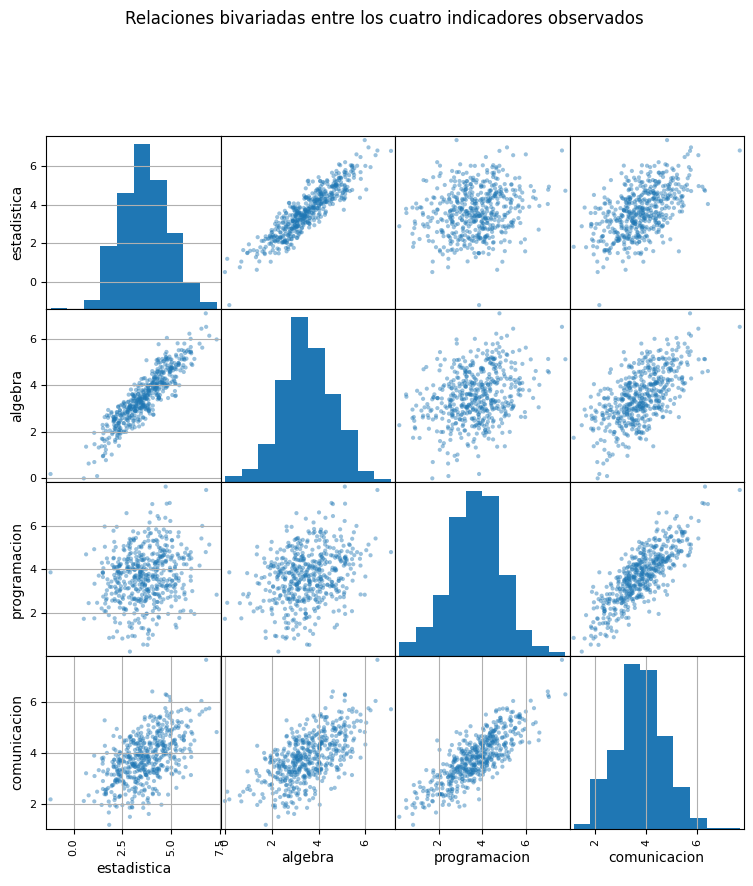

In [ ]:
# @title Visualización inicial: relaciones entre variables observadas

pd.plotting.scatter_matrix(df, alpha=0.45, figsize=(9, 9), diagonal="hist")
plt.suptitle("Relaciones bivariadas entre los cuatro indicadores observados", y=1.02)
plt.show()

### Lectura inicial

La estructura bivariada muestra patrones diferenciados entre grupos de variables:

- **estadística y álgebra** presentan una relación lineal fuerte y positiva → comparten una fuente común de variación;
- **programación y comunicación** también muestran una relación lineal clara → sugieren otro eje estructural;
- las relaciones cruzadas entre estos dos bloques son **más débiles y dispersas**, lo que indica que no todo se explica por un único factor global;
- las distribuciones marginales son aproximadamente unimodales y con dispersión comparable.

En conjunto, la nube sugiere que los datos no son completamente arbitrarios en $\mathbb{R}^4$, sino que están organizados alrededor de una estructura de menor dimensión (posiblemente $k=2$), con dispersión alrededor de esa estructura.

PCA identificará esas direcciones de máxima varianza.  
PPCA permitirá interpretar esa estructura como el resultado de **factores latentes más un componente explícito de ruido**.

## 4. PCA aplicado al ejemplo conductor

Antes de introducir PPCA formalmente, repetimos PCA con la notación ya usada.

Primero centramos los datos:

$$
X_c = X - \mathbf{1}\bar{x}^T.
$$

Luego calculamos

$$
S = \frac{1}{n-1}X_c^T X_c.
$$

Después hacemos

$$
S = Q\Lambda Q^T.
$$

Finalmente, los scores son

$$
Z = X_c Q.
$$

In [ ]:
# @title Construcción manual de PCA con la notación del curso

X_mat = df.values
x_bar = X_mat.mean(axis=0)
X_c = X_mat - x_bar

S = (X_c.T @ X_c) / (n - 1)

eigvals, eigvecs = eigh(S)
idx = np.argsort(eigvals)[::-1]

lambda_vals = eigvals[idx]
Q = eigvecs[:, idx]
Lambda = np.diag(lambda_vals)

Z = X_c @ Q

tabla_pca = pd.DataFrame({
    "Componente": [f"PC{j}" for j in range(1, p + 1)],
    "Autovalor": lambda_vals,
    "Varianza explicada": lambda_vals / lambda_vals.sum(),
    "Varianza acumulada": np.cumsum(lambda_vals / lambda_vals.sum())
})

tabla_pca

,Componente,Autovalor,Varianza explicada,Varianza acumulada
0,PC1,3.404208,0.659130,0.659130
1,PC2,1.520655,0.294433,0.953563
2,PC3,0.130979,0.025360,0.978923
3,PC4,0.108855,0.021077,1.000000


In [ ]:
# @title Cargas de PCA

tabla_cargas_pca = pd.DataFrame(
    Q,
    index=variables,
    columns=[f"PC{j}" for j in range(1, p + 1)]
)

tabla_cargas_pca

,PC1,PC2,PC3,PC4
estadistica,-0.559501,-0.486581,0.411425,-0.530025
algebra,-0.548749,-0.337411,-0.670013,0.368933
programacion,-0.430898,0.746598,-0.261994,-0.433910
comunicacion,-0.447392,0.303288,0.559617,0.628239


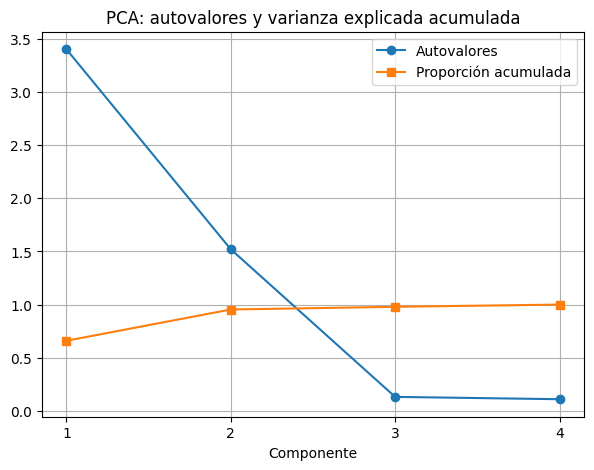

In [ ]:
# @title Scree plot y varianza explicada acumulada

fig, ax = plt.subplots()

componentes = np.arange(1, p + 1)

ax.plot(componentes, lambda_vals, marker="o", label="Autovalores")
ax.plot(componentes, np.cumsum(lambda_vals / lambda_vals.sum()), marker="s", label="Proporción acumulada")
ax.set_xticks(componentes)
ax.set_xlabel("Componente")
ax.set_title("PCA: autovalores y varianza explicada acumulada")
ax.legend()

plt.show()

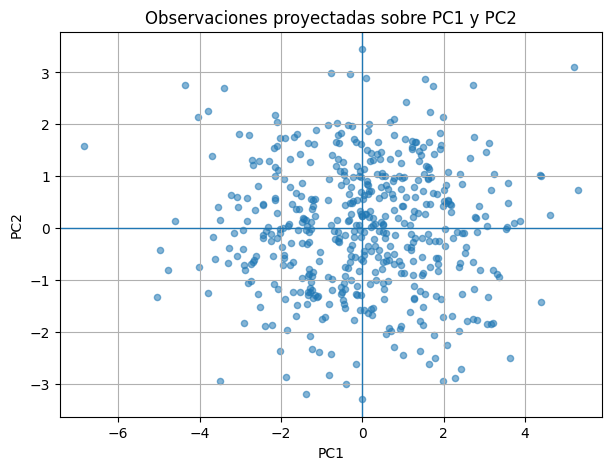

In [ ]:
# @title Scores de PCA en las dos primeras componentes

fig, ax = plt.subplots()

ax.scatter(Z[:, 0], Z[:, 1], alpha=0.55, s=20)
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Observaciones proyectadas sobre PC1 y PC2")

plt.show()

### Lectura de PCA en el ejemplo

La proyección sobre $(PC1,PC2)$ muestra que las observaciones quedan organizadas en un plano donde:

- la mayor dispersión ocurre a lo largo de $PC1$ → esta componente captura la principal fuente de variabilidad;
- $PC2$ recoge variación adicional, pero de menor magnitud;
- la nube es aproximadamente elíptica y centrada en el origen (consistente con datos centrados);
- no se observan agrupamientos claros, sino una estructura continua de variación.

Esto confirma que gran parte de la información en $\mathbb{R}^4$ puede representarse en $\mathbb{R}^2$ sin pérdida sustancial de varianza.

Sin embargo, esta representación sigue siendo **puramente geométrica**:

- $Z = X_c Q$ es una proyección, no una variable latente con interpretación probabilística;
- no hemos especificado un mecanismo generativo para los datos;
- la dispersión alrededor de las direcciones principales no está modelada explícitamente como ruido;
- no podemos asignar probabilidades a nuevas observaciones;
- no existe, en este marco, una distribución para “los factores” que generan los datos.

Para responder estas limitaciones, introducimos PPCA, que mantiene la estructura espectral de PCA pero la incorpora dentro de un modelo probabilístico generativo.

## 5. De PCA a PPCA: cambio conceptual

En PCA trabajamos principalmente con el problema geométrico:

$$
S = Q\Lambda Q^T.
$$

La matriz $Q$ define direcciones y $\Lambda$ mide varianzas.

En PPCA cambiamos la pregunta.

En lugar de preguntar solamente por las direcciones de máxima varianza, preguntamos:

> ¿Existe un vector latente $z \in \mathbb{R}^k$ que genera un vector observado $x \in \mathbb{R}^p$ mediante una transformación lineal más ruido?

Aquí $k < p$.

En el ejemplo:

- $p=4$ porque observamos cuatro indicadores;
- $k=2$ porque suponemos dos factores latentes principales;
- $z$ representa la posición latente de un estudiante;
- $x$ representa los indicadores observados del estudiante.

## 6. Modelo generativo de PPCA

Sea $x \in \mathbb{R}^p$ un vector observado. En PPCA se supone que

$$
x = Wz + \mu + \varepsilon,
$$

donde:

- $z \in \mathbb{R}^k$ es un vector latente;
- $W \in \mathbb{R}^{p \times k}$ es la matriz de cargas del modelo;
- $\mu \in \mathbb{R}^p$ es el vector de medias;
- $\varepsilon \in \mathbb{R}^p$ es ruido aleatorio.

El supuesto probabilístico básico es

$$
z \sim \mathcal{N}(0,I_k),
$$

y

$$
\varepsilon \sim \mathcal{N}(0,\sigma^2 I_p).
$$

Además, $z$ y $\varepsilon$ son independientes.

Así, la distribución condicional de $x$ dado $z$ es

$$
x|z \sim \mathcal{N}(Wz+\mu,\sigma^2 I_p).
$$

Esta ecuación dice que, si conociéramos la posición latente $z$, el vector observado $x$ estaría alrededor de $Wz+\mu$, con ruido isotrópico de varianza $\sigma^2$.

## 7. Significado de cada objeto (con interpretabilidad)

### Idea clave (interpretabilidad)

PPCA permite pasar de una descripción geométrica a una interpretación estructural:

> las variables observadas $x$ se explican como manifestaciones de pocos factores latentes $z$, más ruido.

Por ejemplo, si un estudiante tiene

$$
z=
\begin{pmatrix}
1.5\\
-0.5
\end{pmatrix},
$$

podemos interpretar (si el modelo lo permite) que:

- tiene alto **razonamiento cuantitativo** ($z_1$ alto);
- tiene menor **habilidad de implementación** ($z_2$ bajo).

Ese perfil latente se transforma en observables mediante $W$.

---

### Variable latente $z$

El vector

$$
z = (z_1,\dots,z_k)^T
$$

representa la posición no observada de una observación en un espacio de menor dimensión.

En nuestro ejemplo con $k=2$:

$$
z_1 \approx \text{razonamiento cuantitativo}, \qquad
z_2 \approx \text{implementación computacional}.
$$

Importante:

- $z$ **no se observa**;
- se **infiere** a partir de $x$;
- su interpretación depende de la estructura de $W$.

---

### Matriz de cargas $W$

La matriz

$$
W \in \mathbb{R}^{p \times k}
$$

indica cómo los factores latentes generan las variables observadas.

- filas: variables (estadística, álgebra, etc.);
- columnas: factores latentes.

Ejemplo conceptual:

$$
W \approx
\begin{pmatrix}
0.9 & 0.1\\
0.8 & 0.2\\
0.1 & 0.9\\
0.3 & 0.7
\end{pmatrix}
$$

Interpretación:

- estadística y álgebra dependen principalmente de $z_1$;
- programación depende de $z_2$;
- comunicación mezcla ambos factores.

Aquí es donde surge la **interpretabilidad** del modelo.

---

### Ruido $\varepsilon$

El término

$$
\varepsilon
$$

representa la variación que **no puede ser explicada por los factores latentes**.

El supuesto

$$
\varepsilon \sim \mathcal{N}(0,\sigma^2 I_p)
$$

implica tres cosas simultáneamente:

1. **Media cero**:
   $$
   E(\varepsilon)=0
   $$

2. **Homocedasticidad**:
   $$
   \mathrm{Var}(\varepsilon_j)=\sigma^2 \quad \forall j
   $$
   todas las variables tienen el mismo nivel de ruido.

3. **No correlación entre errores**:
   $$
   \mathrm{Cov}(\varepsilon_i,\varepsilon_j)=0 \quad (i\neq j)
   $$

Además, el ruido es **isotrópico**:

- tiene la misma intensidad en todas las direcciones;
- la dispersión alrededor de $Wz+\mu$ es “esférica”.

---

### Lectura final

El modelo completo

$$
x = Wz + \mu + \varepsilon
$$

se interpreta como:

- $Wz+\mu$: estructura sistemática (explicada por factores);
- $\varepsilon$: variación residual (ruido).

Así, PPCA separa explícitamente:

> **estructura latente interpretable** + **ruido no explicado**.

## 8. Distribución marginal de $x$

A partir del modelo

$$
x = Wz + \mu + \varepsilon,
$$

con

$$
z \sim \mathcal{N}(0,I_k)
$$

y

$$
\varepsilon \sim \mathcal{N}(0,\sigma^2 I_p),
$$

podemos calcular la media de $x$:

$$
E(x) = E(Wz+\mu+\varepsilon).
$$

Como $E(z)=0$ y $E(\varepsilon)=0$, entonces

$$
E(x)=\mu.
$$

Ahora calculemos la covarianza:

$$
\mathrm{Cov}(x)=\mathrm{Cov}(Wz+\varepsilon).
$$

Como $z$ y $\varepsilon$ son independientes,

$$
\mathrm{Cov}(x)=W\mathrm{Cov}(z)W^T+\mathrm{Cov}(\varepsilon).
$$

Usando

$$
\mathrm{Cov}(z)=I_k
$$

y

$$
\mathrm{Cov}(\varepsilon)=\sigma^2 I_p,
$$

obtenemos

$$
\mathrm{Cov}(x)=WW^T+\sigma^2 I_p.
$$

Por tanto,

$$
x \sim \mathcal{N}(\mu,C),
$$

donde

$$
C = WW^T+\sigma^2 I_p.
$$

### Lectura estadística

PPCA dice que la covarianza observada se descompone en dos partes:

$$
C = WW^T+\sigma^2 I_p.
$$

La parte

$$
WW^T
$$

representa estructura común explicada por los factores latentes.

La parte

$$
\sigma^2 I_p
$$

representa ruido no explicado.

Esta es una diferencia fundamental frente a PCA puro: PPCA separa explícitamente estructura y ruido.

## 9. Estimación de PPCA mediante máxima verosimilitud

PPCA permite estimar los parámetros

$$
\mu,\quad W,\quad \sigma^2.
$$

La estimación de $\mu$ es la media muestral:

$$
\hat \mu = \bar{x}.
$$

Para estimar $W$ y $\sigma^2$, se usa la descomposición espectral de la covarianza muestral:

$$
S = Q\Lambda Q^T.
$$

Recordemos que

$$
\Lambda = \mathrm{diag}(\lambda_1,\dots,\lambda_p),
$$

con

$$
\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_p.
$$

Si elegimos dimensión latente $k$, la estimación de máxima verosimilitud de la varianza de ruido es

$$
\hat{\sigma}^2 = \frac{1}{p-k}\sum_{j=k+1}^{p}\lambda_j.
$$

Es decir, PPCA interpreta los autovalores no retenidos como ruido promedio.

### Construcción de la estimación de $\hat W$

Queremos entender de dónde sale la forma

$$
\hat W = Q_k(\Lambda_k-\hat{\sigma}^2 I_k)^{1/2}.
$$

Partimos de dos hechos clave:

1. En PPCA, la covarianza del modelo es

$$
C = WW^T + \sigma^2 I_p.
$$

2. En los datos, la covarianza muestral tiene descomposición espectral

$$
S = Q \Lambda Q^T.
$$

---

### Paso 1: Alinear direcciones

Buscamos que el modelo reproduzca la estructura principal de $S$.  
La forma más natural es exigir que las direcciones de $WW^T$ coincidan con las de PCA:

$$
Q_k = [q_1,\dots,q_k].
$$

Esto implica que la parte estructural del modelo vive en el subespacio generado por los primeros $k$ autovectores.

---

### Paso 2: Separar varianza en “señal + ruido”

En la dirección $q_j$, la varianza total observada es $\lambda_j$.

Pero en PPCA esa varianza se descompone como:

$$
\lambda_j = \text{varianza explicada por factores} + \text{ruido}.
$$

Como el ruido es isotrópico,

$$
\text{ruido} = \sigma^2.
$$

Por tanto, la parte explicada por el factor en la dirección $q_j$ debe ser

$$
\lambda_j - \sigma^2.
$$

---

### Paso 3: Construir $WW^T$

Queremos que

$$
WW^T
$$

tenga:

- direcciones: $q_1,\dots,q_k$;
- varianzas: $\lambda_1-\sigma^2,\dots,\lambda_k-\sigma^2$.

Eso implica que

$$
WW^T = Q_k(\Lambda_k - \sigma^2 I_k)Q_k^T.
$$

---

### Paso 4: Construir una matriz $W$ que produzca esa covarianza

Queremos que la parte estructural del modelo cumpla

$$
WW^T = Q_k(\Lambda_k-\sigma^2I_k)Q_k^T.
$$

Ahora notemos que la matriz

$$
\Lambda_k-\sigma^2I_k
$$

es diagonal:

$$
\Lambda_k-\sigma^2I_k
=
\begin{pmatrix}
\lambda_1-\sigma^2 & 0 & \cdots & 0\\
0 & \lambda_2-\sigma^2 & \cdots & 0\\
\vdots & \vdots & \ddots & \vdots\\
0 & 0 & \cdots & \lambda_k-\sigma^2
\end{pmatrix}.
$$

Como sus entradas representan varianzas explicadas por los factores, necesitamos una matriz cuyas columnas tengan escala

$$
\sqrt{\lambda_j-\sigma^2}.
$$

Por eso definimos

$$
D_k =
(\Lambda_k-\sigma^2I_k)^{1/2}
=
\begin{pmatrix}
\sqrt{\lambda_1-\sigma^2} & 0 & \cdots & 0\\
0 & \sqrt{\lambda_2-\sigma^2} & \cdots & 0\\
\vdots & \vdots & \ddots & \vdots\\
0 & 0 & \cdots & \sqrt{\lambda_k-\sigma^2}
\end{pmatrix}.
$$

Entonces tomamos

$$
W = Q_kD_k.
$$

Verifiquemos qué ocurre:

$$
WW^T
=
(Q_kD_k)(Q_kD_k)^T.
$$

Como

$$
(Q_kD_k)^T = D_k^TQ_k^T,
$$

tenemos

$$
WW^T
=
Q_kD_kD_k^TQ_k^T.
$$

Pero $D_k$ es diagonal, entonces

$$
D_kD_k^T = D_k^2 = \Lambda_k-\sigma^2I_k.
$$

Por tanto,

$$
WW^T
=
Q_k(\Lambda_k-\sigma^2I_k)Q_k^T.
$$

Esto es exactamente lo que queríamos.

Por eso, usando la estimación de ruido $\hat{\sigma}^2$, obtenemos

$$
\hat W
=
Q_k(\Lambda_k-\hat{\sigma}^2I_k)^{1/2}.
$$
---

### Lectura final

- $Q_k$: fija las **direcciones principales** (las mismas de PCA);
- $\Lambda_k$: contiene la **varianza total** en esas direcciones;
- $\hat{\sigma}^2 I_k$: resta la parte atribuida al **ruido**;
- la raíz cuadrada transforma varianza en **escala de cargas**.

Así, PPCA toma la estructura espectral de PCA y la descompone explícitamente en:

> **estructura latente (factores)** + **ruido isotrópico**.

In [ ]:
# @title Estimación de PPCA desde la descomposición espectral de S

from IPython.display import display, Markdown

def ajustar_ppca_desde_pca(X, k, nombres_variables=None):
    n, p = X.shape

    mu_hat = X.mean(axis=0)
    X_c = X - mu_hat

    S = (X_c.T @ X_c) / (n - 1)

    eigvals, eigvecs = eigh(S)
    idx = np.argsort(eigvals)[::-1]

    lambda_vals = eigvals[idx]
    Q = eigvecs[:, idx]

    Q_k = Q[:, :k]
    lambda_k = lambda_vals[:k]
    Lambda_k = np.diag(lambda_k)

    sigma2_hat = np.mean(lambda_vals[k:]) if k < p else 0.0

    valores_ajustados = np.maximum(lambda_k - sigma2_hat, 0)
    W_hat = Q_k @ np.diag(np.sqrt(valores_ajustados))

    C_hat = W_hat @ W_hat.T + sigma2_hat * np.eye(p)

    if nombres_variables is None:
        nombres_variables = [f"x{j}" for j in range(1, p + 1)]

    return {
        "n": n,
        "p": p,
        "k": k,
        "mu_hat": mu_hat,
        "X_c": X_c,
        "S": S,
        "Q": Q,
        "lambda_vals": lambda_vals,
        "Q_k": Q_k,
        "Lambda_k": Lambda_k,
        "sigma2_hat": sigma2_hat,
        "W_hat": W_hat,
        "C_hat": C_hat,
        "nombres_variables": nombres_variables
    }


ppca_k2 = ajustar_ppca_desde_pca(X_mat, k=2, nombres_variables=variables)

tabla_mu = pd.DataFrame({
    "Variable": ppca_k2["nombres_variables"],
    "Media estimada": ppca_k2["mu_hat"]
})

tabla_autovalores = pd.DataFrame({
    "Autovalor": [f"lambda_{j}" for j in range(1, ppca_k2["p"] + 1)],
    "Valor": ppca_k2["lambda_vals"],
    "Interpretación": [
        "estructura latente" if j <= ppca_k2["k"] else "ruido promedio"
        for j in range(1, ppca_k2["p"] + 1)
    ]
})

tabla_Qk = pd.DataFrame(
    ppca_k2["Q_k"],
    index=ppca_k2["nombres_variables"],
    columns=[f"q_{j}" for j in range(1, ppca_k2["k"] + 1)]
)

tabla_Lambdak = pd.DataFrame(
    ppca_k2["Lambda_k"],
    index=[f"lambda_{j}" for j in range(1, ppca_k2["k"] + 1)],
    columns=[f"lambda_{j}" for j in range(1, ppca_k2["k"] + 1)]
)

tabla_W = pd.DataFrame(
    ppca_k2["W_hat"],
    index=ppca_k2["nombres_variables"],
    columns=[f"factor_latente_{j}" for j in range(1, ppca_k2["k"] + 1)]
)

tabla_C = pd.DataFrame(
    ppca_k2["C_hat"],
    index=ppca_k2["nombres_variables"],
    columns=ppca_k2["nombres_variables"]
)

display(Markdown("### Dimensiones del problema"))
display(Markdown(
    f"$n={ppca_k2['n']}$ observaciones, "
    f"$p={ppca_k2['p']}$ variables observadas, "
    f"$k={ppca_k2['k']}$ factores latentes."
))

display(Markdown("### Media estimada $\\hat\\mu$"))
display(tabla_mu)

display(Markdown("### Autovalores de $S$"))
display(tabla_autovalores)

display(Markdown("### Varianza de ruido estimada $\\hat\\sigma^2$"))
display(Markdown(
    f"$\\hat\\sigma^2 = {ppca_k2['sigma2_hat']:.6f}$"
))

display(Markdown("### Matriz $Q_k$: autovectores principales retenidos"))
display(tabla_Qk)

display(Markdown("### Matriz $\\Lambda_k$: autovalores principales retenidos"))
display(tabla_Lambdak)

display(Markdown("### Matriz de cargas estimada $\\hat W$"))
display(tabla_W)

display(Markdown("### Matriz de covarianza estimada por PPCA $\\hat C = \\hat W\\hat W^T + \\hat\\sigma^2 I_p$"))
display(tabla_C)

### Dimensiones del problema

$n=500$ observaciones, $p=4$ variables observadas, $k=2$ factores latentes.

### Media estimada $\hat\mu$

,Variable,Media estimada
0,estadistica,3.648489
1,algebra,3.515564
2,programacion,3.682966
3,comunicacion,3.794729


### Autovalores de $S$

...

,lambda_1,lambda_2
lambda_1,3.404208,0.000000
lambda_2,0.000000,1.520655


### Matriz de cargas estimada $\hat W$

,factor_latente_1,factor_latente_2
estadistica,-1.013962,-0.575883
algebra,-0.994476,-0.399336
programacion,-0.780901,0.883619
comunicacion,-0.810792,0.358950


### Matriz de covarianza estimada por PPCA $\hat C = \hat W\hat W^T + \hat\sigma^2 I_p$

,estadistica,algebra,programacion,comunicacion
estadistica,1.479677,1.238332,0.282943,0.615399
algebra,1.238332,1.268368,0.423726,0.662972
programacion,0.282943,0.423726,1.510506,0.950324
comunicacion,0.615399,0.662972,0.950324,0.906146


### Nota importante sobre la no unicidad de $W$

La matriz $\hat W$ no es única. Si $R$ es una matriz ortogonal de tamaño $k \times k$, entonces

$$
\hat W R
$$

genera la misma matriz de covarianza, porque

$$
(\hat W R)(\hat W R)^T = \hat W RR^T \hat W^T = \hat W \hat W^T.
$$

Por esta razón, los ejes latentes de PPCA pueden rotarse sin cambiar el modelo marginal de $x$.

En este notebook usaremos la solución alineada con los autovectores de PCA:

$$
\hat W = Q_k(\Lambda_k-\hat{\sigma}^2 I_k)^{1/2}.
$$

In [ ]:
# @title Comparación entre S y C_hat

from IPython.display import display, Markdown, HTML

S_hat = ppca_k2["S"]
C_hat = ppca_k2["C_hat"]

tabla_S = pd.DataFrame(S_hat, index=variables, columns=variables)
tabla_C = pd.DataFrame(C_hat, index=variables, columns=variables)
tabla_diff = pd.DataFrame(S_hat - C_hat, index=variables, columns=variables)

display(Markdown("### Comparación entre $S$ y $\\hat C$"))

html = f"""
<div style="display:flex; gap:30px; align-items:flex-start;">
  <div>
    <h4>Matriz de covarianza muestral: S</h4>
    {tabla_S.round(4).to_html()}
  </div>
  <div>
    <h4>Matriz de covarianza estimada por PPCA: C_hat</h4>
    {tabla_C.round(4).to_html()}
  </div>
</div>
"""

display(HTML(html))

display(Markdown("### Diferencia $S-\\hat C$"))
display(tabla_diff.round(6))

### Comparación entre $S$ y $\hat C$

,estadistica,algebra,programacion,comunicacion
estadistica,1.4784,1.2374,0.2792,0.6216
algebra,1.2374,1.2718,0.4274,0.6563
programacion,0.2792,0.4274,1.5092,0.9517
comunicacion,0.6216,0.6563,0.9517,0.9052
,estadistica,algebra,programacion,comunicacion
estadistica,1.4797,1.2383,0.2829,0.6154
algebra,1.2383,1.2684,0.4237,0.6630
programacion,0.2829,0.4237,1.5105,0.9503
comunicacion,0.6154,0.6630,0.9503,0.9061


### Diferencia $S-\hat C$

,estadistica,algebra,programacion,comunicacion
estadistica,-0.001235,-0.000886,-0.003736,0.006230
algebra,-0.000886,0.003460,0.003713,-0.006712
programacion,-0.003736,0.003713,-0.001323,0.001394
comunicacion,0.006230,-0.006712,0.001394,-0.000902


### Comparación entre $S$ y $\hat C$

La tabla compara la covarianza muestral

$$
S=\frac{1}{n-1}X_c^TX_c
$$

con la covarianza estimada por PPCA

$$
\hat C = \hat W \hat W^T + \hat\sigma^2 I_p.
$$

Se observa que:

- los valores de $S$ y $\hat C$ son muy cercanos;
- las diferencias son pequeñas y oscilan alrededor de cero.

Esto indica que el modelo PPCA logra **reproducir adecuadamente la estructura de covarianza de los datos**, descomponiéndola en:

- una parte estructural: $\hat W \hat W^T$;
- una parte de ruido: $\hat\sigma^2 I_p$.

En otras palabras, PPCA aproxima bien $S$ usando un modelo de menor dimensión más ruido.

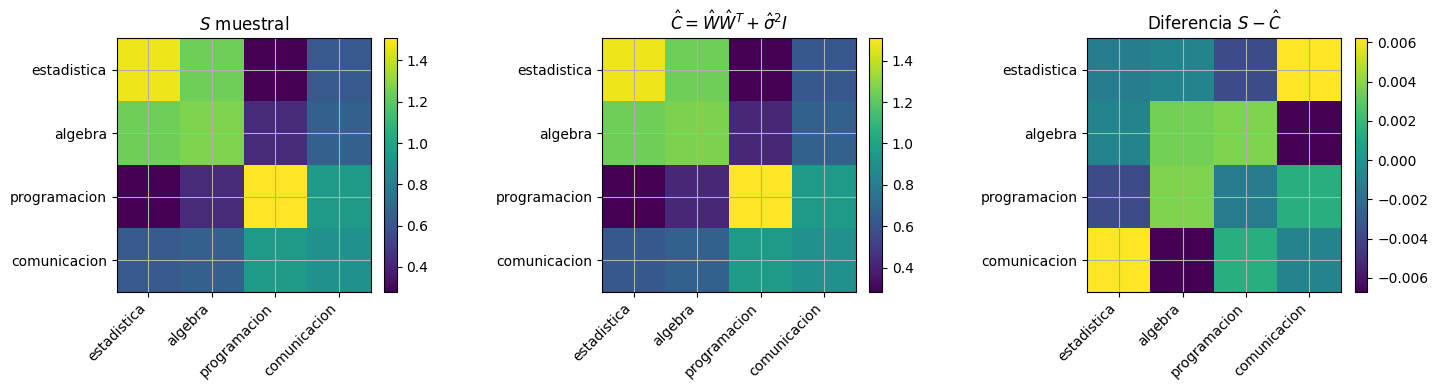

In [ ]:
# @title Mapas de calor: covarianza muestral vs covarianza estimada por PPCA

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

matrices = [S_hat, C_hat, S_hat - C_hat]
titulos = [r"$S$ muestral", r"$\hat C = \hat W\hat W^T + \hat\sigma^2 I$", r"Diferencia $S-\hat C$"]

for ax, M, titulo in zip(axes, matrices, titulos):
    im = ax.imshow(M)
    ax.set_title(titulo)
    ax.set_xticks(range(p))
    ax.set_yticks(range(p))
    ax.set_xticklabels(variables, rotation=45, ha="right")
    ax.set_yticklabels(variables)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 10. Ejemplo guiado de interpretación

En nuestro ejemplo, la matriz $\hat W$ resume cómo los factores latentes se expresan en las variables observadas.

Una forma práctica de leerla es:

- si una variable tiene carga alta en el primer factor, esa variable está fuertemente asociada con $z_1$;
- si una variable tiene carga alta en el segundo factor, esa variable está fuertemente asociada con $z_2$;
- si una variable tiene cargas relevantes en ambos factores, mezcla dimensiones latentes.

Recordemos que esta lectura no es causal. Es una lectura estructural del modelo.

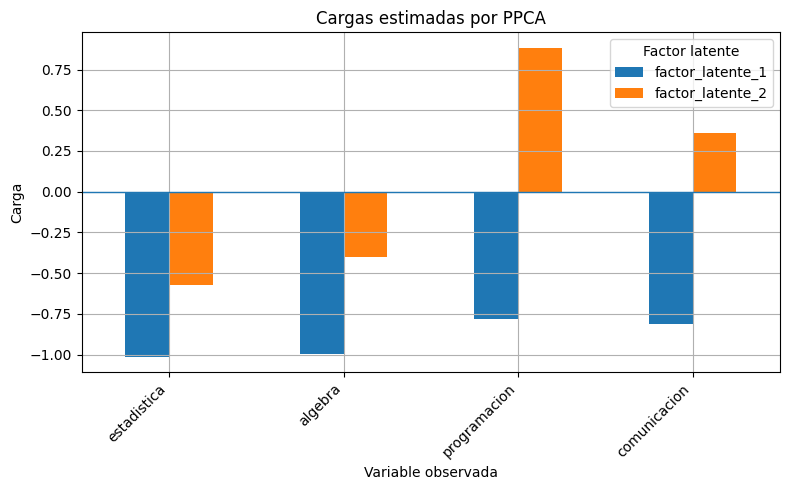

In [ ]:
# @title Visualización de las cargas PPCA

tabla_W.plot(kind="bar", figsize=(8, 5))
plt.axhline(0, linewidth=1)
plt.title("Cargas estimadas por PPCA")
plt.ylabel("Carga")
plt.xlabel("Variable observada")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Factor latente")
plt.tight_layout()
plt.show()

## 11. Ejercicios para resolver en clase

### Ejercicio 1. De PCA a PPCA

Explique, con sus palabras, qué pregunta responde PCA y qué pregunta adicional responde PPCA.

Debe usar en su respuesta los objetos:

$$
S,\quad Q,\quad \Lambda,\quad W,\quad z,\quad \sigma^2.
$$

---

### Ejercicio 2. Covarianza marginal en PPCA

Partiendo de

$$
x = Wz+\mu+\varepsilon,
$$

con

$$
z \sim \mathcal{N}(0,I_k)
$$

y

$$
\varepsilon \sim \mathcal{N}(0,\sigma^2I_p),
$$

demuestre que

$$
\mathrm{Cov}(x)=WW^T+\sigma^2I_p.
$$

---

### Ejercicio 3. Cálculo manual de $\hat\sigma^2$

Suponga que los autovalores de $S$ son

$$
\lambda_1=5.2,\quad \lambda_2=2.1,\quad \lambda_3=0.6,\quad \lambda_4=0.4.
$$

Si se ajusta un modelo PPCA con $k=2$, calcule

$$
\hat{\sigma}^2.
$$

Interprete el resultado.

---

### Ejercicio 4. Cargas de PPCA usando la salida del notebook

Usando la tabla de autovalores, la matriz $Q_k$ y el valor estimado de $\hat\sigma^2$ obtenidos en el notebook, calcule manualmente:

$$
\hat W = Q_k(\Lambda_k-\hat{\sigma}^2I_k)^{1/2}.
$$

Luego compare su resultado con la matriz $\hat W$ mostrada por Python.

Interprete qué variables cargan más sobre cada factor latente.

---

### Ejercicio 5. Simulación

Simule datos desde el modelo

$$
x = Wz+\mu+\varepsilon,
$$

con $p=3$ y $k=1$.

Use:

$$
W =
\begin{pmatrix}
1.5 \\
1.0 \\
0.4
\end{pmatrix},
$$

$$
\mu =
\begin{pmatrix}
0 \\
0 \\
0
\end{pmatrix},
$$

y pruebe tres valores de ruido:

$$
\sigma = 0.1,\quad \sigma = 0.5,\quad \sigma = 1.0.
$$

Para cada caso:

1. grafique los datos;
2. calcule PCA;
3. estime PPCA;
4. compare $\hat\sigma^2$ con el ruido usado en la simulación.

---

### Ejercicio 6. Interpretación crítica

En el ejemplo de estudiantes, discuta si los factores latentes pueden interpretarse como:

1. razonamiento cuantitativo;
2. implementación computacional.

Use la matriz de cargas $\hat W$ para justificar su respuesta.

---

### Ejercicio 7. Comparación conceptual

Complete la siguiente frase:

> PCA transforma los datos mediante una proyección; PPCA interpreta los datos como...

La respuesta debe mencionar:

$$
z,\quad W,\quad \mu,\quad \varepsilon,\quad \sigma^2.
$$

---

### Ejercicio adicional. Comparación entre $S$ y $\hat C$

Explique por qué $S$ y $\hat C$ pueden compararse aunque el modelo PPCA use $k=2$ factores latentes y los datos observados tengan $p=4$ variables.

En su respuesta debe mencionar las dimensiones de:

$$
z,\quad W,\quad WW^T,\quad \sigma^2I_p,\quad \hat C.
$$